# **Import Library Example**

In [0]:
from pyspark.sql.functions import col
from pyspark.sql.functions import avg, col
from pyspark.sql.functions import month, year, sum as sum_
from pyspark.sql.functions import sum as sum_
from pyspark.sql.functions import col, sum as sum_, count
import matplotlib.pyplot as plt
from pyspark.sql.functions import sum
import pandas as pd
from pyspark.sql.functions import when
from pyspark.sql.functions import lit
import numpy as np
from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.ml.classification import DecisionTreeClassifier, RandomForestClassifier, LogisticRegression
from pyspark.ml.regression import LinearRegression
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, RegressionEvaluator
from pyspark.ml.evaluation import ClusteringEvaluator
import seaborn as sns
import mlflow

# Data Loading and Import

In this step, the dataset is loaded into the Databricks environment using Apache Spark. The dataset is read from the specified file path in CSV format, with headers enabled and schema automatically inferred.

This process converts the raw dataset into a Spark DataFrame, which allows efficient distributed data processing and analysis.

In [0]:
df = spark.read.csv("/Workspace/Users/devindidadigama@gmail.com/Dataset/online_retail_II.csv", header=True, inferSchema=True)

# Dataset Overview

After loading the dataset, an initial exploration is performed to understand its structure, size, and attributes. This step is important to gain a clear understanding of the data before proceeding with preprocessing and analysis.

In [0]:
print("Row count:", df.count())
print("Column count:", len(df.columns))
print("Columns:", df.columns)

Row count: 1067371
Column count: 8
Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


In [0]:
display(df.limit(10))

Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01T07:45:00.000Z,6.95,13085.0,United Kingdom
489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01T07:45:00.000Z,6.75,13085.0,United Kingdom
489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01T07:45:00.000Z,6.75,13085.0,United Kingdom
489434,22041,"""RECORD FRAME 7"""" SINGLE SIZE """,48,2009-12-01T07:45:00.000Z,2.1,13085.0,United Kingdom
489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01T07:45:00.000Z,1.25,13085.0,United Kingdom
489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01T07:45:00.000Z,1.65,13085.0,United Kingdom
489434,21871,SAVE THE PLANET MUG,24,2009-12-01T07:45:00.000Z,1.25,13085.0,United Kingdom
489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01T07:45:00.000Z,5.95,13085.0,United Kingdom
489435,22350,CAT BOWL,12,2009-12-01T07:46:00.000Z,2.55,13085.0,United Kingdom
489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01T07:46:00.000Z,3.75,13085.0,United Kingdom


# Data Visualization 

## Top 10 most popular products by total quantity sold

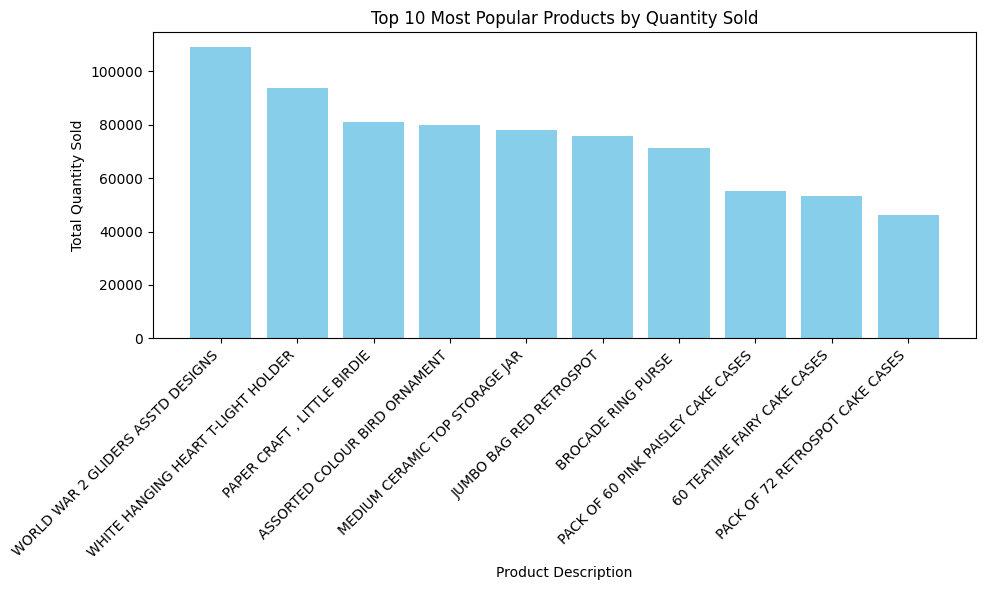

In [0]:
# Top 10 most popular products by total quantity sold
top_products_pdf = popular_products.limit(10).toPandas()
plt.figure(figsize=(10,6))
plt.bar(top_products_pdf['Description'], top_products_pdf['TotalQuantity'], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Most Popular Products by Quantity Sold')
plt.xlabel('Product Description')
plt.ylabel('Total Quantity Sold')
plt.tight_layout()
plt.show()

## Monthly revenue trend over time

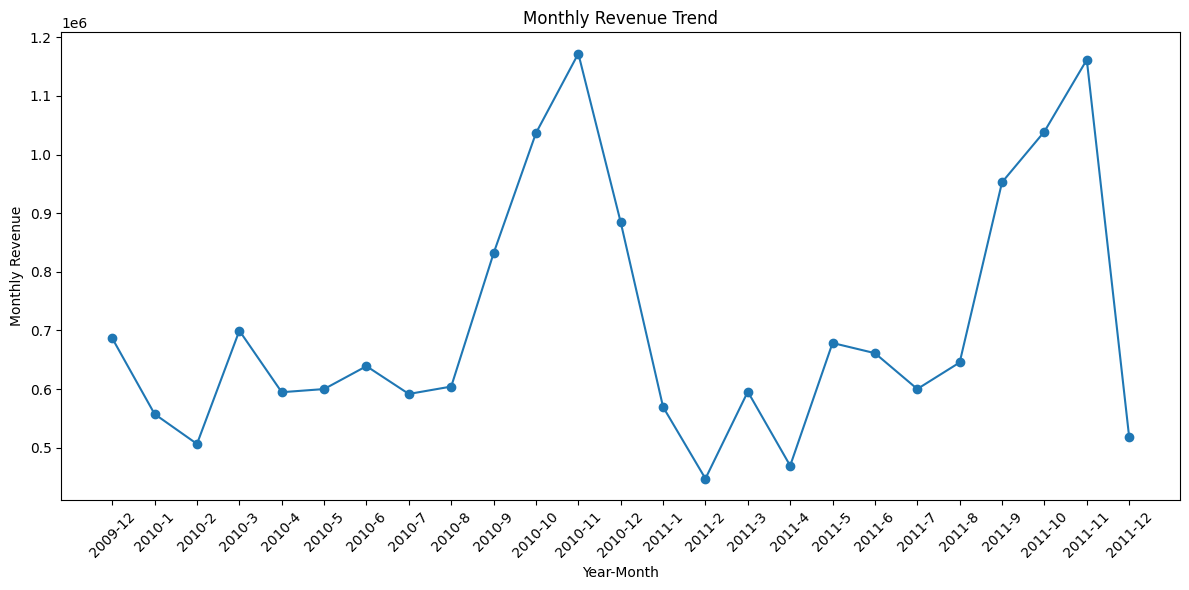

In [0]:
# Monthly revenue trend over time
monthly_revenue_pdf = monthly_revenue.toPandas()
monthly_revenue_pdf['YearMonth'] = monthly_revenue_pdf['Year'].astype(str) + '-' + monthly_revenue_pdf['Month'].astype(str)
plt.figure(figsize=(12,6))
plt.plot(monthly_revenue_pdf['YearMonth'], monthly_revenue_pdf['MonthlyRevenue'], marker='o')
plt.xticks(rotation=45)
plt.title('Monthly Revenue Trend')
plt.xlabel('Year-Month')
plt.ylabel('Monthly Revenue')
plt.tight_layout()
plt.show()

## Distribution of sales by country (top 5 countries)

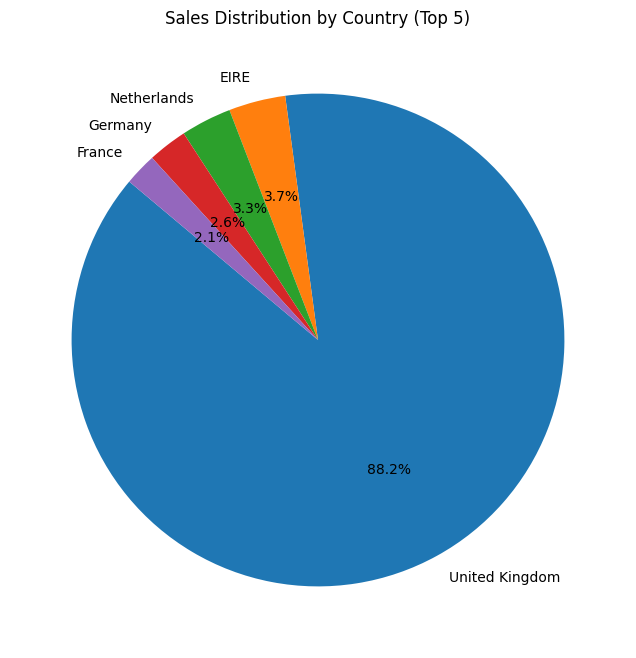

In [0]:
# Distribution of sales by country (top 5 countries)
country_sales = df_clean.groupBy("Country").agg(sum("Sales").alias("TotalSales")).orderBy("TotalSales", ascending=False).limit(5).toPandas()
plt.figure(figsize=(8,8))
plt.pie(country_sales['TotalSales'], labels=country_sales['Country'], autopct='%1.1f%%', startangle=140)
plt.title('Sales Distribution by Country (Top 5)')
plt.show()

## verage sales per product (top 10)

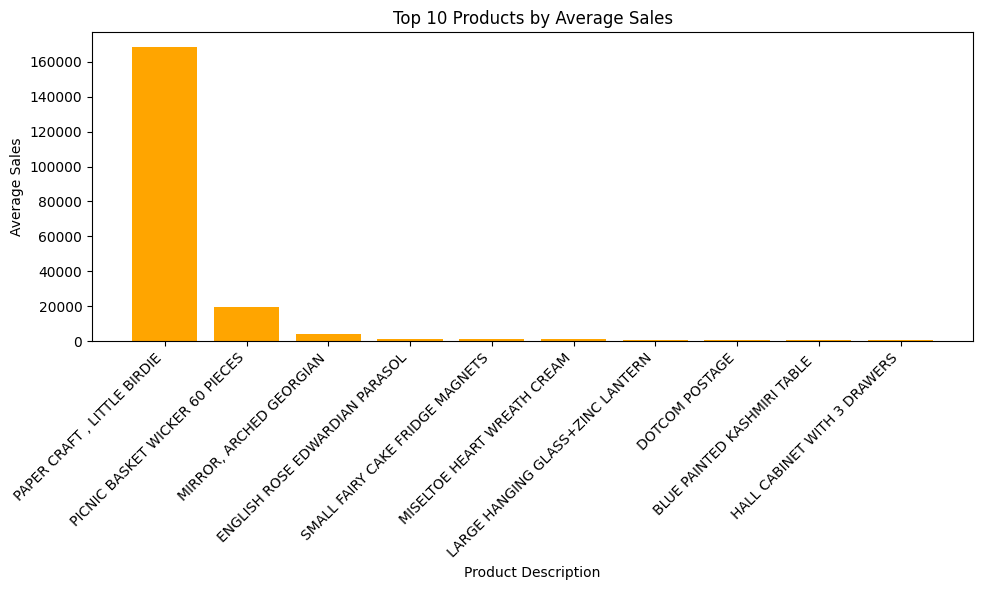

In [0]:

# Average sales per product (top 10)
avg_sales_pdf = avg_sales_per_product.limit(10).toPandas()
plt.figure(figsize=(10,6))
plt.bar(avg_sales_pdf['Description'], avg_sales_pdf['AvgSales'], color='orange')
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Products by Average Sales')
plt.xlabel('Product Description')
plt.ylabel('Average Sales')
plt.tight_layout()
plt.show()

## Number of purchases per customer (top 10 customers)

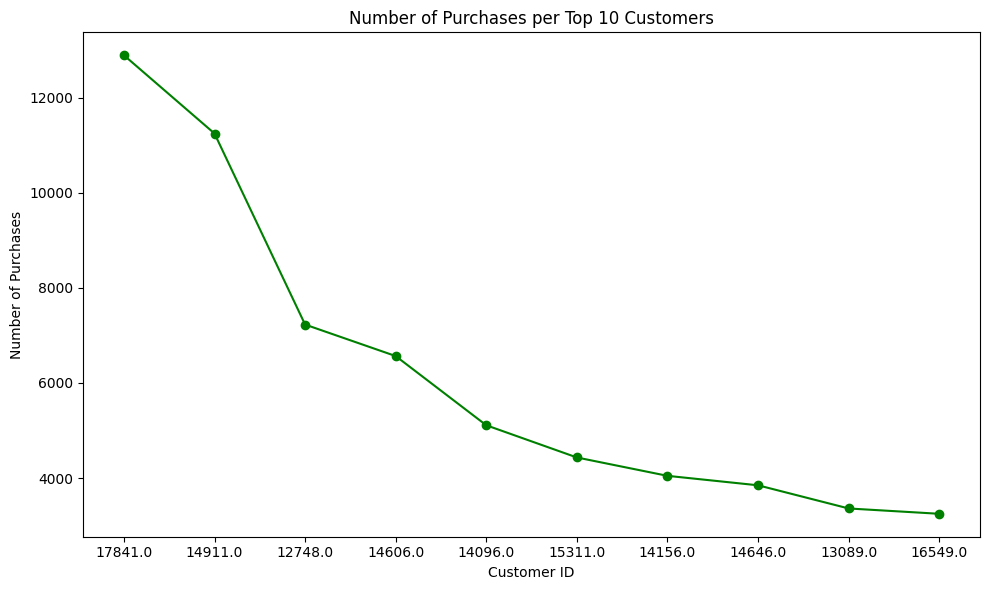

In [0]:
# Number of purchases per customer (top 10 customers)
top_customers_pdf = customer_patterns.orderBy("NumPurchases", ascending=False).limit(10).toPandas()
plt.figure(figsize=(10,6))
plt.plot(top_customers_pdf['CustomerID'].astype(str), top_customers_pdf['NumPurchases'], marker='o', color='green')
plt.title('Number of Purchases per Top 10 Customers')
plt.xlabel('Customer ID')
plt.ylabel('Number of Purchases')
plt.tight_layout()
plt.show()

##  Share of total sales by top 10 customers

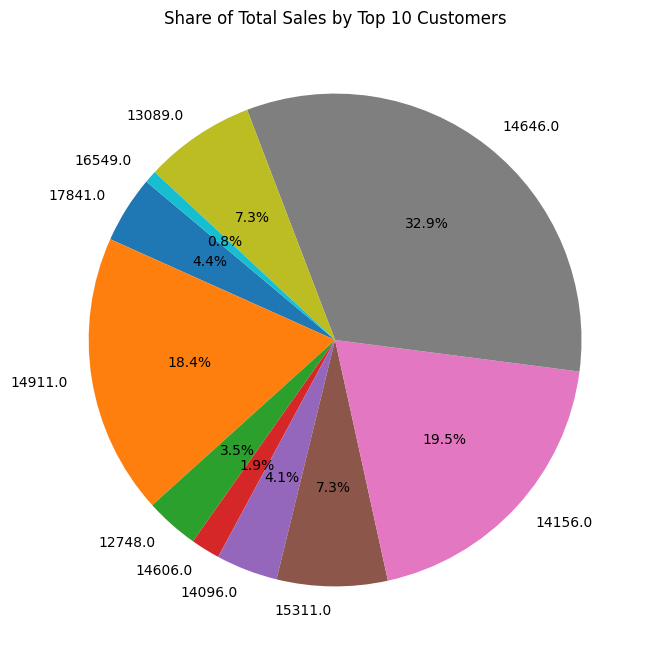

In [0]:
# Share of total sales by top 10 customers
plt.figure(figsize=(8,8))
plt.pie(top_customers_pdf['TotalSales'], labels=top_customers_pdf['CustomerID'].astype(str), autopct='%1.1f%%', startangle=140)
plt.title('Share of Total Sales by Top 10 Customers')
plt.show()


## elationship between quantity and sales per transaction

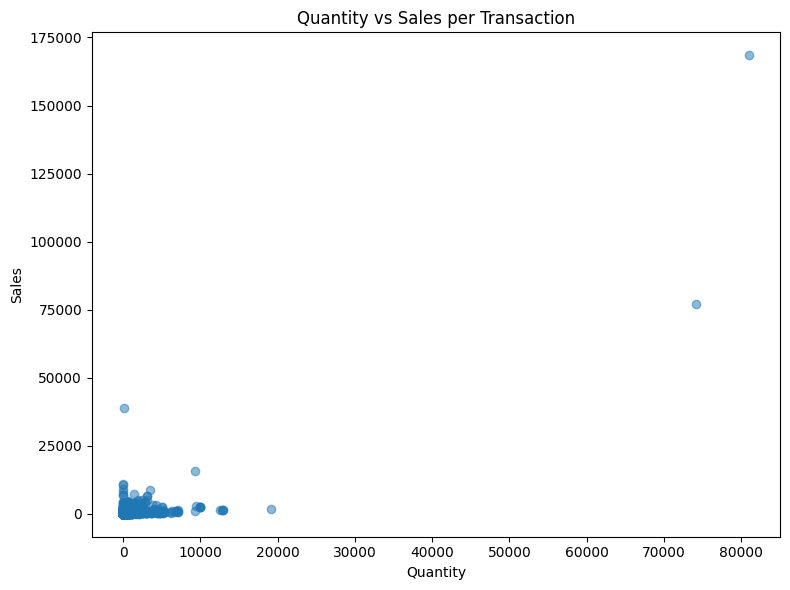

In [0]:

# Relationship between quantity and sales per transaction
transaction_pdf = df_clean.select("Quantity", "Sales").toPandas()
plt.figure(figsize=(8,6))
plt.scatter(transaction_pdf['Quantity'], transaction_pdf['Sales'], alpha=0.5)
plt.title('Quantity vs Sales per Transaction')
plt.xlabel('Quantity')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

## Total sales by month (aggregated across years)

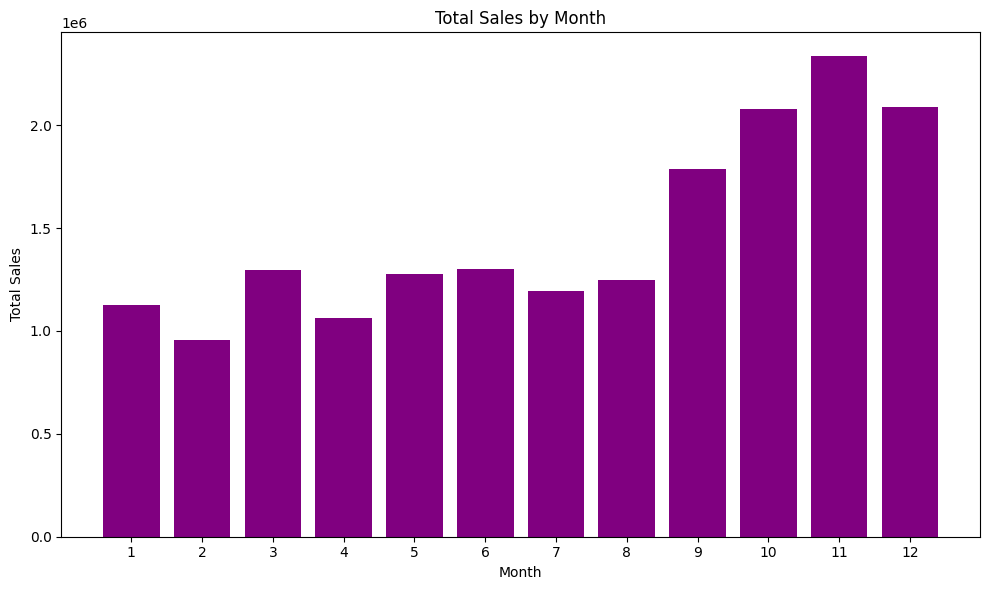

In [0]:

# Total sales by month (aggregated across years)
monthly_sales_pdf = df_clean.groupBy("Month").agg(sum("Sales").alias("TotalSales")).orderBy("Month").toPandas()
plt.figure(figsize=(10,6))
plt.bar(monthly_sales_pdf['Month'].astype(str), monthly_sales_pdf['TotalSales'], color='purple')
plt.title('Total Sales by Month')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()
# Explanation:
# This bar chart shows total sales for each month, aggregated across all years, revealing seasonal sales patterns.

## Total sales and number of purchases by product type (Description)

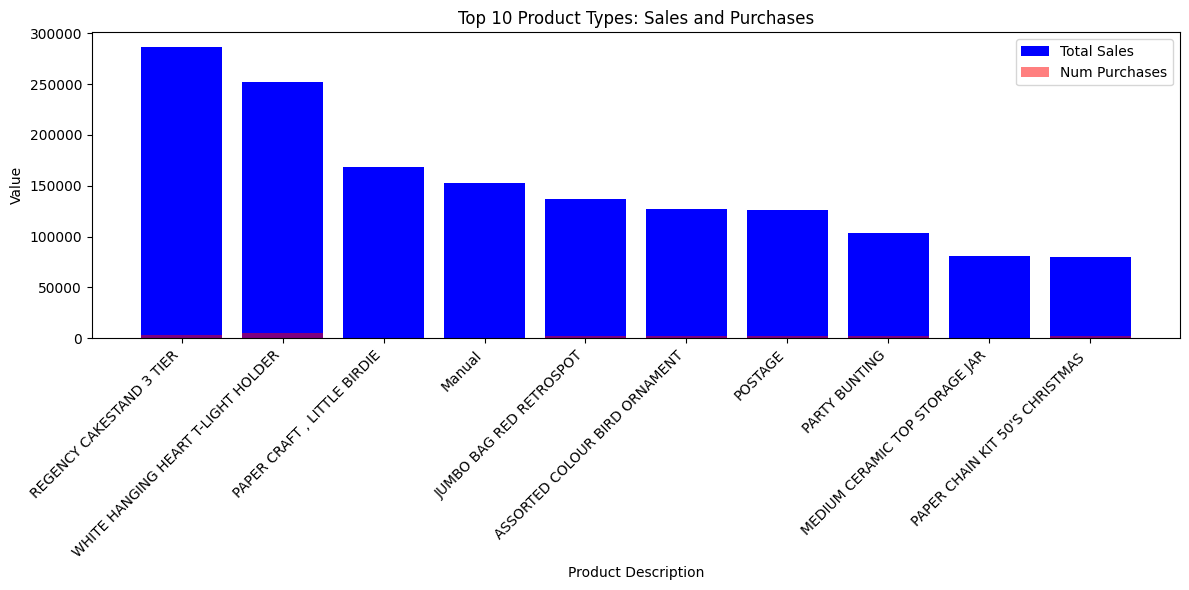

In [0]:
# Total sales and number of purchases by product type (Description)
product_type_stats = df_clean.groupBy("Description").agg(
    sum_("Sales").alias("TotalSales"),
    count("InvoiceNo").alias("NumPurchases")
).orderBy("TotalSales", ascending=False).limit(10).toPandas()

plt.figure(figsize=(12,6))
plt.bar(product_type_stats['Description'], product_type_stats['TotalSales'], color='blue', label='Total Sales')
plt.bar(product_type_stats['Description'], product_type_stats['NumPurchases'], color='red', alpha=0.5, label='Num Purchases')
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Product Types: Sales and Purchases')
plt.xlabel('Product Description')
plt.ylabel('Value')
plt.legend()
plt.tight_layout()
plt.show()

## correlation matrix from numeric columns

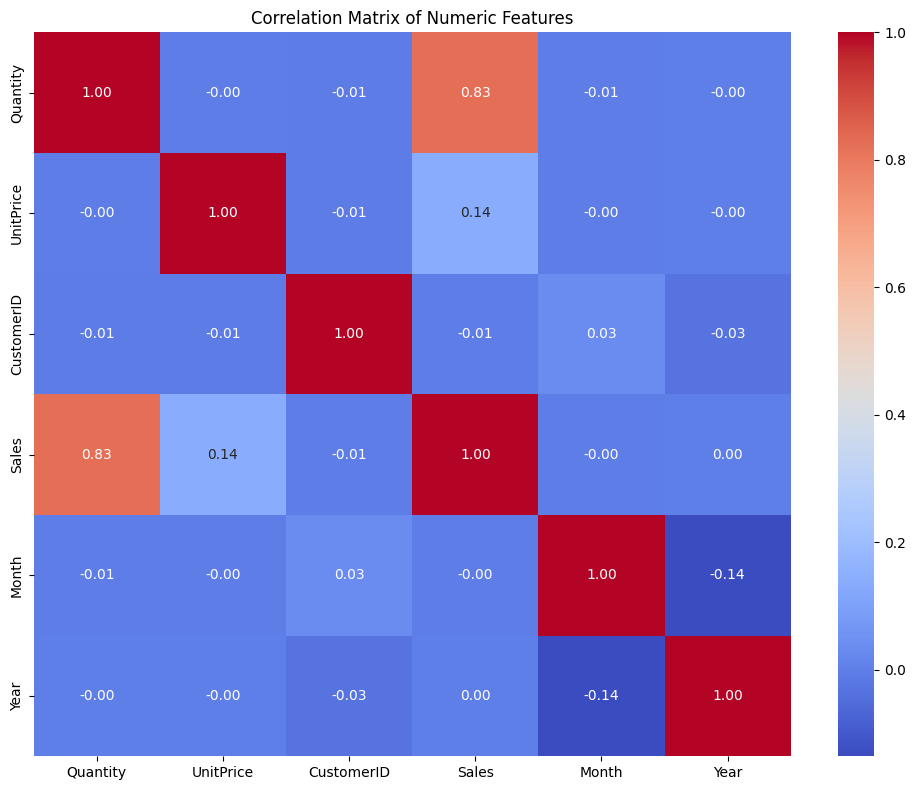

In [0]:
# correlation matrix from numeric columns
numeric_cols = ['Quantity', 'UnitPrice', 'CustomerID', 'Sales', 'Month', 'Year']
corr_matrix = df_clean.select(numeric_cols).toPandas().corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", xticklabels=corr_matrix.columns, yticklabels=corr_matrix.columns)
plt.title("Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.show()